In [1]:
import os
os.environ["XDG_CACHE_HOME"] = "/ceph/hpc/home/ciangottinid/.cache"
import skimage

In [2]:
from tqdm import tqdm
import torch
import numpy as np
import xarray as xr
from skimage.metrics import structural_similarity as ssim
from scipy.stats import entropy
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

from Fires._utilities.metrics import WeightedBCE_L1Loss
from Fires._utilities.utils_mlflow import load_model_from_mlflow

from Fires._utilities.utils_inference import compute_aggregated_mape_smape,load_input_data, create_data_loader, process_and_plot_data, get_prov_image

In [3]:
run_name=input()
registered_model = load_model_from_mlflow(run_name, provenance=True)
registered_model 

 lastone


Data from MLFlow downloaded in: /jupyter-workspace/persistent-storage/ML4Fires/MLFLOW/lastone


UnetPlusPlus(
  (activation): Sigmoid()
  (pool_2x2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (pool_3x3): MaxPool2d(kernel_size=(3, 3), stride=(3, 3), padding=0, dilation=1, ceil_mode=False)
  (up_2x2): Upsample(scale_factor=(2.0, 2.0), mode='bilinear')
  (up_3x3): Upsample(scale_factor=(3.0, 3.0), mode='bilinear')
  (conv0_0): VGGBlock(
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv1_0): VGGBlock(
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Co

In [4]:
# define path to complete dataset
data_path = "/ceph/hpc/home/ciangottinid/ML4Fires/data/ML4Fires_copy/data_100km.zarr"

input_data = load_input_data(data_path, '2019', '2020')
input_data

['lai', 'rel_hum', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)


<xarray.Dataset> Size: 167MB
Dimensions:    (time: 92, latitude: 180, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * time       (time) datetime64[ns] 736B 2019-01-01 2019-01-09 ... 2020-12-26
Data variables:
    lai        (time, latitude, longitude) float32 24MB nan nan nan ... nan nan
    rel_hum    (time, latitude, longitude) float32 24MB 89.11 89.19 ... 61.39
    t2m_min    (time, latitude, longitude) float32 24MB 246.2 246.2 ... 242.5
    tp         (time, latitude, longitude) float32 24MB 1.802 1.802 ... 0.3219
    lsm        (time, latitude, longitude) float32 24MB 0.0 0.0 0.0 ... 1.0 1.0
    fcci_ba    (time, latitude, longitude) float64 48MB nan nan nan ... 0.0 0.0
Attributes:
    crs:          EPSG:4326
    description:  The SeasFire Cube is a scientific datacube for seasonal fir...
    title:        SeasFire Cube: A Global Dataset for Seasonal Fire Modeling ...

In [5]:
torch_data_loader = create_data_loader(data_path, run_name)

In [6]:
preds = []
with torch.no_grad():
	for data, _ in tqdm(torch_data_loader):
		prediction = registered_model(data.to('cuda:0'))
		prediction_cpu = prediction.cpu().numpy()
		preds.append(prediction_cpu)
preds_array = np.vstack(preds)

100%|██████████| 92/92 [00:01<00:00, 70.87it/s] 


In [11]:
import torch
# This is very sensitive to zero pixels.
def compute_temporal_mape_smape(input_tensor: torch.Tensor,
                                preds_tensor: torch.Tensor):
    """
    Compute MAPE and sMAPE per time step, then average across time steps.
    Supports both:
      • 1‑D (T,) → treats the single axis as “time.”
      • N‑D with shape (T, *S) → averages over spatial dims S for each t.

    Args:
        input_tensor: torch.Tensor of shape (T, *spatial_dims) or (T,)
        preds_tensor: torch.Tensor of same shape
    Returns:
        mape_avg, smape_avg: float
    """
    eps = 1e-6  # to avoid division by zero

    # shape check
    if input_tensor.shape != preds_tensor.shape:
        raise ValueError(f"Shape mismatch: {input_tensor.shape} vs {preds_tensor.shape}")

    # 1D case: just time series
    if input_tensor.ndim == 1:
        # absolute percentage error at each time
        ape = torch.abs((input_tensor - preds_tensor) / (input_tensor + eps)) * 100
        mape_avg = ape.mean().item()

        # symmetric ape
        sap = 2 * torch.abs(preds_tensor - input_tensor) / (
            torch.abs(input_tensor) + torch.abs(preds_tensor) + eps
        ) * 100
        smape_avg = sap.mean().item()
        return mape_avg, smape_avg

    # ND case: first dim = time, rest = spatial
    if input_tensor.ndim < 2:
        raise ValueError(f"Tensor must have at least 1D time + spatial dims, got {input_tensor.ndim}D")

    # all dims except time
    spatial_dims = tuple(range(1, input_tensor.ndim))

    # 1) per‑time abs pct error, then mean over spatial dims → (T,)
    ape = torch.abs((input_tensor - preds_tensor) / (input_tensor + eps))
    mape_ts = ape.mean(dim=spatial_dims) * 100

    # 2) per‑time symmetric APE, mean over spatial dims → (T,)
    sap = 2 * torch.abs(preds_tensor - input_tensor) / (
        torch.abs(input_tensor) + torch.abs(preds_tensor) + eps
    )
    smape_ts = sap.mean(dim=spatial_dims) * 100

    # 3) average over time
    mape_avg = mape_ts.mean().item()
    smape_avg = smape_ts.mean().item()

    return mape_avg, smape_avg

mape, smape = compute_temporal_mape_smape(input_tensor, preds_tensor)
print(f"Time-averaged MAPE: {mape:.2f}%, sMAPE: {smape:.2f}%")


Time-averaged MAPE: 3460.83%, sMAPE: 53.88%


In [7]:
input_tensor = torch.tensor(input_data["fcci_ba"].values, dtype=torch.float32)
preds_tensor = torch.tensor(preds_array, dtype=torch.float32)

    # Ensure preds_tensor has the correct shape by squeezing singleton dimension
preds_tensor = preds_tensor.squeeze(1)  # Removes the extra dimension

    # Create a mask for non-NaN values in fcci_ba
nan_mask = ~torch.isnan(input_tensor)  # True for valid values, False for NaNs

    # Apply the mask to remove NaN locations from both input and predictions
input_tensor = input_tensor[nan_mask]
preds_tensor = preds_tensor[nan_mask]
mape_val, smape_val = compute_aggregated_mape_smape(input_tensor, preds_tensor)

print("\n📊 Aggregated Performance Metrics (Summed over Time):")
print(f"✅ MAPE (%):  {mape_val:.4f}")
print(f"✅ sMAPE (%): {smape_val:.4f}")






📊 Aggregated Performance Metrics (Summed over Time):
✅ MAPE (%):  3.8062
✅ sMAPE (%): 3.7351


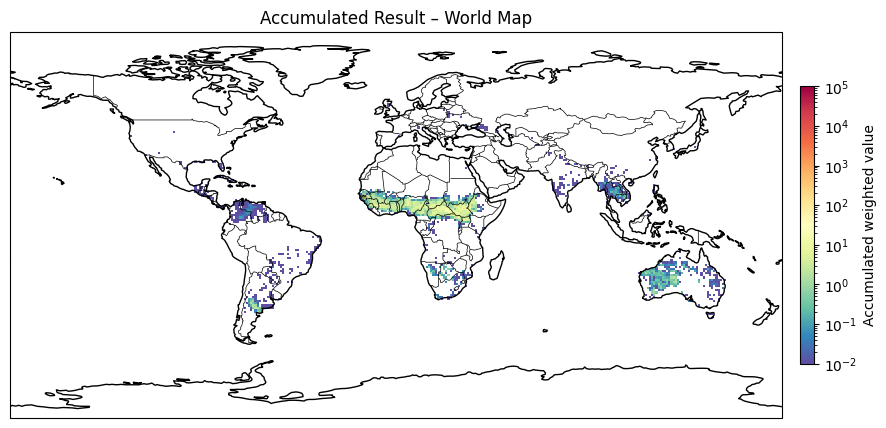

In [8]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ─── (Re)load the final 2D DataArray ─────────────────────────────────────────────
# If you already have k2d in your namespace, you can skip down to the plotting section.
# Otherwise:
mask_path = "/ceph/hpc/home/ciangottinid/ML4Fires/mask.nc"
df = xr.open_dataset(mask_path)
df1 = xr.open_zarr(data_path)

# pick one variable
if isinstance(df1, xr.Dataset):
    df1 = df1[list(df1.data_vars)[0]]

# build k exactly as before, then:
k = xr.zeros_like(df1)
for c in df.cl.values:
    mask_slice = df["basis_regions"].isel(cl=c)
    a1, m1 = xr.align(df1, mask_slice, join="inner")
    w = (a1 * m1).sum().compute().item()
    k += (a1 * m1) * w

k = k.compute()
k2d = k.isel(time=0)   # choose your time slice

# ─── Plot on a map ───────────────────────────────────────────────────────────────
lons = k2d.longitude
lats = k2d.latitude
data2d = k2d.values

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(resolution='110m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# pcolormesh needs the meshgrid of lon/lat:
lon2d, lat2d = np.meshgrid(lons, lats)
im = ax.pcolormesh(
    lon2d, lat2d, data2d,
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.Spectral_r,
    norm=mcolors.LogNorm(vmin=0.01, vmax=100000)
)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label("Accumulated weighted value")

ax.set_title("Accumulated Result – World Map")
plt.show()


 taken the time × lat × lon ML output,

Weighted and summed it region‑by‑region using our 15‑class mask,

Collapsed that into a single time slice,

And drawn it on a global map with a logarithmic Spectral_r colormap and geographic context (coastlines, borders).

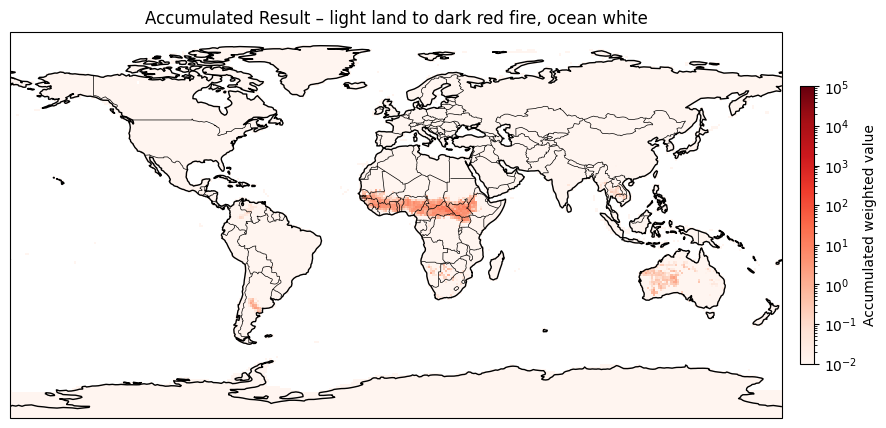

In [16]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ─── (Re)compute or load your 2D result ────────────────────────────────────────
mask_path = "/ceph/hpc/home/ciangottinid/ML4Fires/mask.nc"
df_mask   = xr.open_dataset(mask_path)
df1       = xr.open_zarr(data_path)

# pick the first ML variable if needed
if isinstance(df1, xr.Dataset):
    df1 = df1[list(df1.data_vars)[0]]

# accumulate weighted sums over mask classes
k = xr.zeros_like(df1)
for c in df_mask.cl.values:
    msl = df_mask["basis_regions"].isel(cl=c)
    a1, m1 = xr.align(df1, msl, join="inner")
    w = (a1 * m1).sum().compute().item()
    k += (a1 * m1) * w
k = k.compute()
k2d = k.isel(time=0)  # pick one time slice

# ─── build a land/ocean mask ───────────────────────────────────────────────────
land_mask = (df_mask["basis_regions"].sum(dim="cl") > 0)
_, land_mask = xr.align(k2d, land_mask, join="inner")
land_mask_arr = land_mask.values

# ─── prepare data: ocean=NaN, floor tiny lands to vmin ─────────────────────────
data2d = k2d.values.astype(float)
vmin, vmax = 0.01, 1e5

# ocean stays NaN → white
data2d_masked = np.full_like(data2d, np.nan, dtype=float)
# fill land values
data2d_masked[land_mask_arr] = data2d[land_mask_arr]
# any land below vmin → set to vmin (lightest red)
low_land = land_mask_arr & (data2d_masked < vmin)
data2d_masked[low_land] = vmin

# ─── choose Reds colormap ─────────────────────────────────────────────────────
cmap = plt.cm.Reds.copy()      # sequential reds: light→dark
cmap.set_bad("white")          # ocean (NaN) = white
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# ─── plot on world map ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 6))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

lon2d, lat2d = np.meshgrid(k2d.longitude, k2d.latitude)
im = ax.pcolormesh(
    lon2d, lat2d, data2d_masked,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

cbar = plt.colorbar(im, ax=ax, orientation="vertical", shrink=0.6, pad=0.02)
cbar.set_label("Accumulated weighted value")
ax.set_title("Accumulated Result – light land to dark red fire, ocean white")
plt.show()
